## Импорты и параметры

### Привязываем Гугл-диск

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Импорты библиотек

In [ ]:
!pip install -U transformers
!pip install -q trl bert-score openai
!pip install trl==0.11.3
!pip install -q accelerate>=1.8.0
!pip install -q bitsandbytes>=0.46.1

import time
import random
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
import os
import json

import torch
torch.cuda.empty_cache()

from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead
from transformers import AutoTokenizer, BitsAndBytesConfig, Qwen2ForCausalLM
from bert_score import BERTScorer
import openai
import gc
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 122.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.9.0
    Uninstalling transformers-5.9.0:
      Successfully uninstalled transformers-5.9.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.5 MB/s eta 0:00:00
  Attempting uninstall: trl
    Found existing installation: trl 1.5.1
    Uninstalling trl-1.5.1:
      Successfully uninstalled trl-1.5.1


## Сохраняем параметры дообучения

In [ ]:
# дообучение
USE_LLM_REWARD = True
EPOCHS_NUM = 3
MAX_INPUT_TOKENS = 1024
MAX_OUTPUT_TOKENS = 512

# бащовая модель
MODEL_TO_LEARN = "Qwen/Qwen2.5-1.5B-Instruct"
QUANTIZATION = "4bit"  # 4bit / 8bit
BATCH_SIZE = 1

# параметры LLM-score
OPENROUTER_API_KEY = ""
JUDGE_MODEL = "openai/gpt-oss-120b:free"
LLM_MAX_RETRIES = 5
LLM_BASE_DELAY = 1.0
last_llm_score = 0.0
LLM_CALL_EVERY_N_STEPS = 1

# BERTScore
bertscorer = BERTScorer(lang="ru", rescale_with_baseline=False, device='cpu')

# клиент OpenRouter
if USE_LLM_REWARD:
    openrouter_client = openai.OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY,
        default_headers={"Content-Type": "application/json; charset=utf-8"}
    )

# параметры PPO
ppo_config = PPOConfig(
    batch_size=BATCH_SIZE,
    mini_batch_size=1,
    gradient_accumulation_steps=1,
    learning_rate=3e-6,
    ppo_epochs=4,
    cliprange=0.1,
    cliprange_value=0.1,
    vf_coef=1.0,
    init_kl_coef=1.0,
    target_kl=6.0,
    adap_kl_ctrl=True,
    gamma=1.0,
    lam=0.95,
    seed=27,
    optimize_cuda_cache=True,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(


### Создание папки на Гугл диске

In [ ]:
folder_path = f'/content/drive/MyDrive/ПЗАД проект/new_ppo/ppo_qwen2.5_{MODEL_TO_LEARN.split('-')[-2]}_bs{BATCH_SIZE}_{QUANTIZATION}'
os.makedirs(folder_path, exist_ok=True)

### Загрузка базовой модели

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_TO_LEARN)
tokenizer.pad_token = tokenizer.eos_token

if QUANTIZATION == '4bit':
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16
    )
else:
    bnb_config = BitsAndBytesConfig(
        load_in_8bit=True
    )

base_model = Qwen2ForCausalLM.from_pretrained(
    MODEL_TO_LEARN,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="sdpa"
)

model = AutoModelForCausalLMWithValueHead.from_pretrained(
    base_model,
    device_map="auto",
    is_trainable=True
)

model.gradient_checkpointing_enable()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params} ({100*trainable_params/total_params:.2f}% of {total_params})")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Trainable parameters: 233520129 (26.28% of 888617985)


### Загрузка референтной модели и инициализация тренера

In [ ]:
base_ref = Qwen2ForCausalLM.from_pretrained(
    MODEL_TO_LEARN,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="sdpa"
)
ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(
    base_ref,
    device_map="auto",
    is_trainable=False
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

trainer = PPOTrainer(
    config=ppo_config,
    model=model,
    ref_model=ref_model,
    tokenizer=tokenizer,
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:273: UserWarning: No dataset is provided. Make sure to set config.batch_size to the correct value before training.
  warnings.warn(


### Сохраняем random seed

In [ ]:
def set_random_seed(seed: int = 27):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

set_random_seed()

## Добавление промпта и преобразование датасета

In [ ]:
def build_prompt_ppo(example, tokenizer):
    """Формирует промт (query) как в исходном build_prompt, но без ответа"""
    instruction = f"""You are an expert in interview analysis. Your task is to highlight the thematic codes in the interview text and corresponding quotes.

Act step by step:

1. Carefully review the output format shown in the example below. Remember that each code block must contain "Общий код" (General code), then Quote, then "Конкретный код" (Specific code). The quote must be verbatim and enclosed in quotation marks.
2. Read the interview transcript and the topic. Identify all fragments (quotes) that relate to the interview topic.
3. Group the quotes by general themes — these will be the "Общий код" (General codes). For each general theme, come up with a short name.
4. Within each general code, identify specific meaning aspects — these will be the "конкретный код" (Specific codes). The names of specific codes should reflect the essence of the quote.
5. Generate the answer strictly following the format from the example. Do not add any explanations, do not write words like 'Step 1', 'Step 2' — only the final blocks of codes and quotes.

Format of an output (consists of several general codes, each followed by quotes and specific codes):
**Общий код 1: <generate general code 1>**
"<quote text>" - **<generate specific code 1> (Конкретный код)**
"<quote text>" - **<generate specific code 2> (Конкретный код)**
**Общий код 2: <generate general code 2>**
"<quote text>" - **<generate specific code> (Конкретный код)**
**Общий код <general code number>: <generate general code>**
"<quote text>" - **<generate specific code> (Конкретный код)**
and so on. You choose the number of general and specific codes.

Example of a topic:
ПОКОЛЕНЧЕСКАЯ ИДЕНТИЧНОСТЬ, ЖИЗНЕННЫЕ ВЫБОРЫ И УСТОЙЧИВОСТЬ РОССИЙСКОЙ МОЛОДЕЖИ

Example of a general code related to the topic (pay attention to the structure):
**Общий код 1: Поколенческие характеристики, ценности и жизненные ориентиры**
"Мне кажется, большинство особо не стремятся там вот срочно, прямо сейчас там жениться, замуж, там детей и так далее. Вот. То есть как-то больше сосредоточены даже не на карьере, а на себе, на том, чтобы сложить все для себя вот так, как хочется, да. То есть не просто чтобы там выйти замуж, а чтобы выйти замуж вот по любви, чтобы все было идеально. Вот на какой-то такой идеальности что ли." - **Фокус на самореализации и качественных отношениях (конкретный код)**
"У нашего поколения все-таки все по-другому. Нам не дадут квартиру просто так. Нам не обязательно так просто получить место там где-то на работе и так далее, да. Но при этом у нас гораздо больше возможностей в плане, как сказать, чему-то научиться новому, куда-то поехать, что-то посмотреть, составить свое мнение, там высказать свое мнение даже." - **Осознание свободы выбора и новых возможностей (конкретный код)**
"У детей нынешних у них как будто меньше табу что ли. [...] они спокойно со мной могла поговорить на какие-то откровенные темы, которые мне в ее возрасте, я тоже задумывалась об этом, у меня тоже было какое-то мнение, но я боялась об этом говорить со взрослыми, потому что это было табуировано. [...] Поэтому у них мне кажется растет какое-то более свободное поколение что ли." - **Сравнение с младшим поколением: свобода от табу (конкретный код)**
"Мне кажется, что поколение у нас достаточно трудолюбивое при этом как бы. То есть если человек чего-то хочет добиться в карьерной сфере, ну, человек действительно может приложить там все усилия и добиться этого. Вот. Потому что возможностей супер много сейчас." - **Трудолюбие и вера в возможности (конкретный код)**

Now you should do the markup for the interview according to the plan. Important: The answer should contain only codes and quotes, without unnecessary words and repetitions.
The quotes must be strictly from the text. Give the answer in Russian.
"""

    user_content = f"""Тема интервью:
{example['topic']}

Текст интервью:
{example['transcript']}

Пожалуйста, выполни разметку интервью, каждый общий код в указанном формате:
**Общий код <generate general code>: <general code name>**
"<quote text>" - **<generate specific code> (Конкретный код)**"""

    messages = [
        {"role": "system", "content": instruction},
        {"role": "user", "content": user_content},
    ]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    return prompt

### Загрузка датасета из файлов

In [ ]:
train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('val_data.csv')
test_df = pd.read_csv('test_data.csv')

# валидационный датасет не нужен, на нем тоже обучимся
ppo_train_df = pd.concat([train_df, val_df], ignore_index=True)
# оставляем 70 текстов, т.к. больше не влезает :(
ppo_train_df = ppo_train_df.loc[:70]

ppo_train_dataset = Dataset.from_pandas(ppo_train_df)
test_dataset = Dataset.from_pandas(test_df)

### Функция для добавления промпта

In [ ]:
def prepare_dataset(hf_dataset, tokenizer):
    queries, targets = [], []
    topics, transcripts = [], []
    for ex in hf_dataset:
        queries.append(build_prompt_ppo(ex, tokenizer))
        targets.append(ex['coding'])
        topics.append(ex['topic'])
        transcripts.append(ex['transcript'])
    return Dataset.from_dict(
        {"query": queries, "coding": targets, "topic": topics, "transcript": transcripts}
    )

In [ ]:
ppo_train_dataset = prepare_dataset(ppo_train_dataset, tokenizer)
test_dataset = prepare_dataset(test_dataset, tokenizer)

## Получение Reward

In [ ]:
llm_cache = {}

def get_llm_score(generated_text, source_text, topic):
    cache_key = (generated_text, source_text, topic)
    if cache_key in llm_cache:
        return llm_cache[cache_key]

    if not USE_LLM_REWARD:
        return None

    model = JUDGE_MODEL

    prompt = f"""Ты - социолог-эксперт в открытом кодировании интервью.
Тема интервью: {topic}
Текст интервью: {source_text}

Сгенерированные коды и цитаты (в формате <код>цитата</код>):
{generated_text}

Оцени результат по трём критериям (каждый от 0 до 1):
1. Релевантность - насколько код соответствует содержанию фрагмента интервью с учётом темы.
2. Когерентность - насколько формулировка кода грамматически корректна и стилистически приемлема.
3. Теоретический инсайт - степень соответствия кода концептуальным ожиданиям.

Ответ дай строго в формате: число, число, число (например: 0.85, 0.90, 0.75). Не пиши никаких пояснений."""

    max_retries = 5
    base_delay = 1.0
    max_delay = 30.0

    for attempt in range(max_retries):
        try:
            response = openrouter_client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=50
            )

            if response and hasattr(response, 'choices') and response.choices:
                content = response.choices[0].message.content
                if content:

                    numbers = re.findall(r"(\d+\.?\d*)", content)
                    if len(numbers) >= 3:
                        try:
                            scores = [float(n) for n in numbers[:3]]
                            mean_score = np.mean(scores)
                            mean_score = max(0.0, min(1.0, mean_score))
                            llm_cache[cache_key] = mean_score
                            return mean_score
                        except ValueError:
                            print(f"LLM warning: non-numeric numbers: {numbers}", flush=True)
                    else:
                        print(f"LLM warning: expected 3 numbers, got {len(numbers)}. Content: {content[:200]}", flush=True)
                else:
                    print("LLM warning: empty content", flush=True)
            else:
                print("LLM warning: invalid response structure", flush=True)

            return None

        except Exception as e:
            is_retryable = False
            if hasattr(e, 'status_code'):
                if e.status_code == 429 or (500 <= e.status_code < 600):
                    is_retryable = True
            elif '429' in str(e) or 'rate limit' in str(e).lower():
                is_retryable = True

            if not is_retryable or attempt == max_retries - 1:
                print(f"LLM error (final): {type(e).__name__}: {e}", flush=True)
                return None
            delay = min(base_delay * (2 ** attempt), max_delay)
            jitter = random.uniform(0, 0.1 * delay)
            wait_time = delay + jitter
            print(f"LLM error (retryable): {e}. Retrying in {wait_time:.2f}s... (attempt {attempt+1}/{max_retries})", flush=True)
            time.sleep(wait_time)

    return None

def compute_reward(generated, target, source_text, topic, use_llm=True):
    global last_llm_score
    _, _, bert_f1 = bertscorer.score([generated], [target])
    bert_reward = bert_f1.item()
    if use_llm:
        new_llm = get_llm_score(generated, source_text, topic)
        if new_llm is not None:
            last_llm_score = new_llm
        llm_reward = last_llm_score
    else:
        llm_reward = 0.0
    return bert_reward + llm_reward, bert_reward, llm_reward

## Запуск дообучения

### Функция генерации

In [ ]:
def generate_code(prompt, max_new_tokens=MAX_OUTPUT_TOKENS, num_beams=1, return_tensors=True):
    device = model.pretrained_model.device
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_INPUT_TOKENS).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=num_beams,
            early_stopping=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    response_ids = outputs[0, inputs['input_ids'].shape[1]:]
    if return_tensors:
        return generated, inputs, response_ids
    return generated

### Очистка CUDA

In [ ]:
def clear_cuda_cache():
    """Очистка кэша CUDA памяти"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        gc.collect()
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        return allocated, reserved
    return 0, 0

clear_cuda_cache()

print("Allocated:", round(torch.cuda.memory_allocated()/2**30, 2), "GB")
print("Reserved: ", round(torch.cuda.memory_reserved()/2**30, 2), "GB")
print("Free:     ", round((torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved())/2**30, 2), "GB")

Allocated: 2.15 GB
Reserved:  2.19 GB
Free:      12.37 GB


### Собственно запуск

In [ ]:
epochs = EPOCHS_NUM
total_examples = len(ppo_train_dataset)
batch_size = ppo_config.batch_size
num_full_batches = total_examples // batch_size
device = next(model.parameters()).device

all_losses = []
all_rewards_total = []
all_rewards_bert = []
all_rewards_llm = []

for epoch in range(epochs):
    for batch_idx in tqdm(range(num_full_batches), desc=f"Epoch {epoch+1}"):
        start_idx = batch_idx * batch_size
        end_idx = start_idx + batch_size

        queries = []
        targets = []
        src_texts = []
        topics_list = []

        for idx in range(start_idx, end_idx):
            batch_item = ppo_train_dataset[idx]
            queries.append(batch_item["query"])
            targets.append(batch_item["coding"])
            src_texts.append(batch_item["transcript"])
            topics_list.append(batch_item["topic"])

        # Определяем, нужно ли вызывать LLM на этом батче
        use_llm_here = (batch_idx % LLM_CALL_EVERY_N_STEPS == 0) and USE_LLM_REWARD

        # Сохраняем предикшн, метрики, тензоры для PPO trainer
        preds, input_tensors, output_tensors, rewards_total, rewards_bert, rewards_llm = [], [], [], [], [], []
        for query, target, src, topic in zip(queries, targets, src_texts, topics_list):
            pred, input_tensor, output_tensor = generate_code(query, return_tensors=True)
            preds.append(pred)
            input_tensors.append(input_tensor)
            output_tensors.append(output_tensor)

            total_reward, bert_reward, llm_reward = compute_reward(pred, target, src, topic, use_llm=USE_LLM_REWARD)
            rewards_total.append(total_reward)
            rewards_bert.append(bert_reward)
            rewards_llm.append(bert_reward)

        # Сохраняем индексы промптов для тренера
        query_ids = [q["input_ids"][0] for q in input_tensors]

        # Созраняем метрики (среднее по батчу)
        all_rewards_total.append(np.array(rewards_total).mean())
        all_rewards_bert.append(np.array(rewards_bert).mean())
        all_rewards_llm.append(np.array(rewards_llm).mean())

        del input_tensors, rewards_bert, rewards_llm

        # Шаг PPO
        rewards_tensors = [torch.tensor(r, dtype=torch.float32) for r in rewards_total]
        train_stats = trainer.step(query_ids, output_tensors, rewards_tensors)

        # Извлекаем лосс
        loss_value = train_stats.get('ppo/loss/total', train_stats.get('loss', 0.0))
        if isinstance(loss_value, torch.Tensor):
            loss_value = loss_value.item()

        # Сохраняем лосс (среднее по батчу)
        all_losses.append(loss_value)

        del query_ids, output_tensors, rewards_tensors, rewards_total

        if batch_idx > 0 and batch_idx % 5 == 0:
            print(f'Средний лосс по последним 5 батчам: {np.mean(all_losses[-5:])}')
            print(f'Средний тотал по последним 5 батчам: {np.mean(all_rewards_total[-5:])}')

        torch.cuda.empty_cache()
        gc.collect()

# Сохраняем логи
log_df = pd.DataFrame({
    'step': range(len(all_losses)),
    'loss': all_losses,
    'reward_total': all_rewards_total,
    'reward_bert': all_rewards_bert,
    'reward_llm': all_rewards_llm
})
log_df.to_csv(f'{folder_path}/training_log.csv', index=False)
print(f"Логи сохранены в training_log.csv")

Epoch 1:   0%|          | 0/71 [00:00<?, ?it/s][transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1309: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std_scores = data["scores"].std()
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1336: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output num

Средний лосс по последним 5 батчам: 0.3604400932788849
Средний тотал по последним 5 батчам: 0.46225287715593977


Epoch 1:  11%|█▏        | 8/71 [11:18<1:27:46, 83.59s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.46 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
Epoch 1:  14%|█▍        | 10/71 [14:08<1:25:52, 84.47s/it]

Средний лосс по последним 5 батчам: 0.290916645526886
Средний тотал по последним 5 батчам: 0.4474740343093872


Epoch 1:  21%|██        | 15/71 [21:15<1:19:49, 85.53s/it]

...

Средний лосс по последним 5 батчам: 0.06086245998740196
Средний тотал по последним 5 батчам: 0.44521563649177553


Epoch 3:  94%|█████████▍| 67/71 [1:31:07<05:26, 81.64s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -2.33 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
Epoch 3:  99%|█████████▊| 70/71 [1:35:10<01:21, 81.21s/it]

Средний лосс по последним 5 батчам: 0.03400429263710976
Средний тотал по последним 5 батчам: 0.4486893653869629


Epoch 3: 100%|██████████| 71/71 [1:36:32<00:00, 81.58s/it]

Логи сохранены в training_log.csv


### Вывод метрик обучения

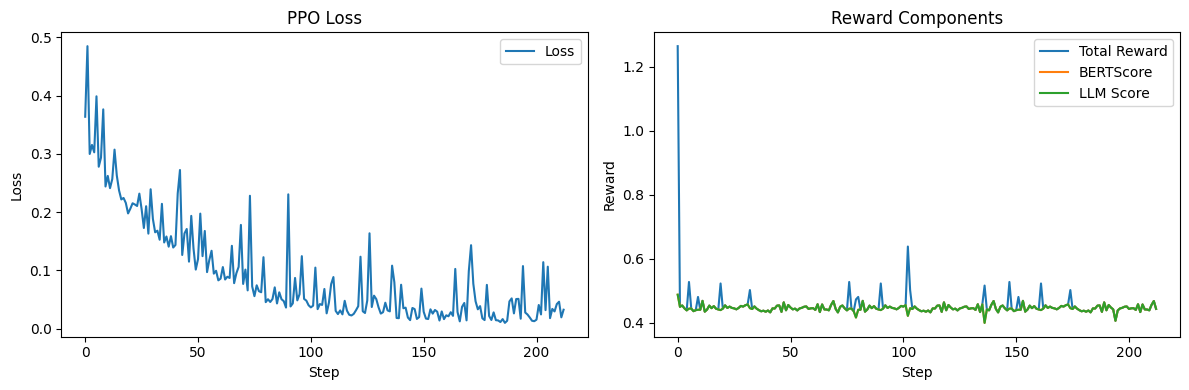

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(log_df['step'], log_df['loss'], label='Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('PPO Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(log_df['step'], log_df['reward_total'], label='Total Reward')
plt.plot(log_df['step'], log_df['reward_bert'], label='BERTScore')
plt.plot(log_df['step'], log_df['reward_llm'], label='LLM Score')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward Components')
plt.legend()
plt.tight_layout()
plt.savefig(f'{folder_path}/training_curves.png')
plt.show()

### Сохранение модели

In [ ]:
model.save_pretrained(folder_path)
tokenizer.save_pretrained(folder_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/ПЗАД проект/new_ppo/ppo_qwen2.5_1.5B_bs1_4bit/tokenizer_config.json',
 '/content/drive/MyDrive/ПЗАД проект/new_ppo/ppo_qwen2.5_1.5B_bs1_4bit/chat_template.jinja',
 '/content/drive/MyDrive/ПЗАД проект/new_ppo/ppo_qwen2.5_1.5B_bs1_4bit/tokenizer.json')